# **Phase 3: Predictive Modeling and Hyperparameter Optimization**        

In [2]:
import os
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

warnings.filterwarnings("ignore")

SEED = 42
X_train_final = pd.read_csv("artifacts/data/X_train_final.csv")
X_val_final = pd.read_csv("artifacts/data/X_val_final.csv")
X_test_final = pd.read_csv("artifacts/data/X_test_final.csv")

y_train = pd.read_csv("artifacts/data/y_train.csv").squeeze()
y_val = pd.read_csv("artifacts/data/y_val.csv").squeeze()
y_test = pd.read_csv("artifacts/data/y_test.csv").squeeze()

X_train_raw = pd.read_csv("artifacts/data/X_train_raw.csv") if Path("artifacts/data/X_train_raw.csv").exists() else None
X_val_raw = pd.read_csv("artifacts/data/X_val_raw.csv") if Path("artifacts/data/X_val_raw.csv").exists() else None
X_test_raw = pd.read_csv("artifacts/data/X_test_raw.csv") if Path("artifacts/data/X_test_raw.csv").exists() else None

X_train_np = np.load("artifacts/data/X_train_np.npy")
X_val_np = np.load("artifacts/data/X_val_np.npy")
X_test_np = np.load("artifacts/data/X_test_np.npy")

y_train_np = np.load("artifacts/data/y_train_np.npy")
y_val_np = np.load("artifacts/data/y_val_np.npy")
y_test_np = np.load("artifacts/data/y_test_np.npy")

with open("artifacts/data/meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

FINAL_COLS = meta["FINAL_COLS"]
cat_idxs = meta["cat_idxs"]
cat_dims = meta["cat_dims"]

print("X_train_final:", X_train_final.shape)
print("X_val_final:", X_val_final.shape)
print("X_test_final:", X_test_final.shape)

X_train_final: (3546, 17)
X_val_final: (760, 17)
X_test_final: (761, 17)


**Experimental Setup**

In [29]:
from sklearn.metrics import (
    f1_score,
    recall_score,
    roc_auc_score,
    precision_score,
    average_precision_score
)

PRIMARY_METRIC = "f1"
SECONDARY_METRIC = "recall"

print("Primary metric:", PRIMARY_METRIC)
print("Secondary metric:", SECONDARY_METRIC)

def evaluate_model(model, X, y, threshold=0.5):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)

    return {
        "F1": f1_score(y, preds),
        "Recall": recall_score(y, preds),
        "Precision": precision_score(y, preds, zero_division=0),
        "ROC_AUC": roc_auc_score(y, probs),
        "PR_AUC": average_precision_score(y, probs)
    }

Primary metric: f1
Secondary metric: recall


**Baseline Models** 

In [111]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

def cross_validate_model(model, X, y, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, preds))

    return np.mean(f1_scores), np.std(f1_scores)

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

rf_model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=SEED,
    use_label_encoder=False,
    eval_metric="logloss"
)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=SEED
)
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_state=SEED
)
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED
)

In [113]:
from sklearn.model_selection import RandomizedSearchCV
xgb_base_for_search = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base_for_search,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=SEED,
    n_jobs=-1
)

xgb_search.fit(X_train_final, y_train)

xgb_tuned_model = xgb_search.best_estimator_
print("Best XGBoost params:", xgb_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [114]:
cat_base_for_search = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_state=42
)

cat_param_dist = {
    "iterations": [300, 500, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "depth": [4, 5, 6, 7, 8],
    "l2_leaf_reg": [1, 3, 5, 7, 9]
}

cat_search = RandomizedSearchCV(
    estimator=cat_base_for_search,
    param_distributions=cat_param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
cat_search.fit(X_train_final, y_train)

cat_tuned_model = cat_search.best_estimator_
print("Best CatBoost Tuned Params:", cat_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CatBoost Tuned Params: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 7}


In [115]:
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "XGBoost Tuned": xgb_tuned_model,
    "MLP": mlp_model,
    "LightGBM": lgb_model,
    "CatBoost": cat_model,
    "CatBoost Tuned": cat_tuned_model
}

In [116]:
from sklearn.metrics import precision_recall_curve

def optimize_threshold(model, X_val, y_val):
    probs = model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, probs)

    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores[:-1])  # thresholds ngắn hơn precision/recall 1 phần tử

    return thresholds[best_idx], f1_scores[best_idx]

In [117]:
# Logistic Regression
training_times = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_final, y_train)
    training_times[name] = time.time() - start

for name, t in training_times.items():
    print(f"{name}: {t:.2f} sec")

[LightGBM] [Info] Number of positive: 587, number of negative: 2959
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000238 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 356
[LightGBM] [Info] Number of data points in the train set: 3546, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.165539 -> initscore=-1.617582
[LightGBM] [Info] Start training from score -1.617582
Logistic Regression: 0.01 sec
Random Forest: 0.90 sec
XGBoost: 0.27 sec
XGBoost Tuned: 0.24 sec
MLP: 2.98 sec
LightGBM: 0.23 sec
CatBoost: 1.11 sec
CatBoost Tuned: 1.47 sec


In [118]:
cv_results = {}
val_results = {}
threshold_results = {}

for name, model in models.items():
    # CV
    mean_f1, std_f1 = cross_validate_model(model, X_train_final, y_train)
    cv_results[name] = {
        "CV_F1_Mean": mean_f1,
        "CV_F1_Std": std_f1
    }

    # Training time
    start_time = time.time()
    model.fit(X_train_final, y_train)
    train_time = time.time() - start_time

    # Validation metrics with default threshold first
    metrics = evaluate_model(model, X_val_final, y_val)
    metrics["Training_Time"] = train_time
    val_results[name] = metrics

    # Best threshold on validation
    best_th, best_f1 = optimize_threshold(model, X_val_final, y_val)
    threshold_results[name] = {
        "Best_Threshold": best_th,
        "Best_F1": best_f1
    }

[LightGBM] [Info] Number of positive: 469, number of negative: 2367
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 347
[LightGBM] [Info] Number of data points in the train set: 2836, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.165374 -> initscore=-1.618776
[LightGBM] [Info] Start training from score -1.618776
[LightGBM] [Info] Number of positive: 470, number of negative: 2367
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 345
[LightGBM] [Info] Number of data points in the train set: 2837, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.165668 -> initscore=-1.616646
[LightGBM] [

In [119]:
cv_df = pd.DataFrame(cv_results).T
val_df = pd.DataFrame(val_results).T
threshold_df = pd.DataFrame(threshold_results).T

comparison_df = pd.concat([cv_df, val_df, threshold_df], axis=1)

comparison_df = comparison_df[
    [
        "CV_F1_Mean",
        "CV_F1_Std",
        "F1",
        "Recall",
        "Precision",
        "ROC_AUC",
        "PR_AUC",
        "Training_Time",
        "Best_Threshold"
    ]
].sort_values("F1", ascending=False)

display(comparison_df)

,CV_F1_Mean,CV_F1_Std,F1,Recall,Precision,ROC_AUC,PR_AUC,Training_Time,Best_Threshold
LightGBM,0.771225,0.041114,0.854626,0.769841,0.960396,0.968842,0.929419,0.222307,0.262603
XGBoost Tuned,0.762798,0.034306,0.843478,0.769841,0.932692,0.965412,0.918012,0.355518,0.268911
XGBoost,0.773317,0.026280,0.842975,0.809524,0.879310,0.961544,0.904927,0.275477,0.435394
CatBoost Tuned,0.780493,0.032694,0.840708,0.753968,0.950000,0.969931,0.917817,1.429458,0.340881
CatBoost,0.748421,0.038097,0.807339,0.698413,0.956522,0.956575,0.890378,1.241427,0.440052
Random Forest,0.704471,0.066052,0.788732,0.666667,0.965517,0.973962,0.918648,0.795063,0.404000
MLP,0.712252,0.047472,0.776860,0.746032,0.810345,0.929235,0.789770,3.018861,0.272447
Logistic Regression,0.474095,0.019206,0.500000,0.769841,0.370229,0.819275,0.539262,0.011367,0.650660


In [39]:
formatted_df = comparison_df.copy()

formatted_df["CV_F1"] = (
    formatted_df["CV_F1_Mean"].round(3).astype(str)
    + " ± "
    + formatted_df["CV_F1_Std"].round(3).astype(str)
)

formatted_df = formatted_df[
    [
        "CV_F1",
        "F1",
        "Recall",
        "Precision",
        "ROC_AUC",
        "PR_AUC",
        "Training_Time",
        "Best_Threshold"
    ]
].round(3)

display(formatted_df)

,CV_F1,F1,Recall,Precision,ROC_AUC,PR_AUC,Training_Time,Best_Threshold
LightGBM,0.771 ± 0.041,0.855,0.770,0.960,0.969,0.929,0.347,0.263
XGBoost Tuned,0.763 ± 0.034,0.843,0.770,0.933,0.965,0.918,0.804,0.269
XGBoost,0.773 ± 0.026,0.843,0.810,0.879,0.962,0.905,0.722,0.435
CatBoost Tuned,0.78 ± 0.033,0.841,0.754,0.950,0.970,0.918,1.808,0.341
CatBoost,0.748 ± 0.038,0.807,0.698,0.957,0.957,0.890,1.524,0.440
Random Forest,0.704 ± 0.066,0.789,0.667,0.966,0.974,0.919,1.304,0.404
MLP,0.712 ± 0.047,0.777,0.746,0.810,0.929,0.790,4.330,0.272
Logistic Regression,0.474 ± 0.019,0.500,0.770,0.370,0.819,0.539,0.011,0.651


***
Kết quả trên tập validation cho thấy các mô hình phi tuyến đạt hiệu quả vượt trội hơn rõ rệt so với **Logistic Regression**. Điều này phù hợp với các phân tích ở giai đoạn EDA, khi dữ liệu cho thấy sự tồn tại của các mối quan hệ phi tuyến và tương tác giữa các biến hành vi.

Xét theo **F1-score**, **LightGBM** là mô hình cho kết quả tốt nhất với **0,855**, đồng thời duy trì **Precision = 0,960**, **Recall = 0,770**, **ROC-AUC = 0,969** và **PR-AUC = 0,929**. Đây là kết quả khá cân bằng giữa khả năng phát hiện khách hàng churn và hạn chế dự đoán dương tính sai.

**XGBoost Tuned** và **XGBoost** cùng đạt **F1 = 0,843**, trong khi **CatBoost Tuned** đạt **F1 = 0,841**. Dù F1 thấp hơn nhẹ so với LightGBM, các mô hình này vẫn cho hiệu suất rất cạnh tranh. Đáng chú ý, **CatBoost Tuned** có **CV_F1 = 0,780 ± 0,033**, cao nhất trong nhóm mô hình được so sánh, cho thấy mức độ ổn định khá tốt trong quá trình cross-validation.

Nếu xét theo khả năng phân biệt lớp, **Random Forest** đạt **ROC-AUC = 0,974**, cao nhất trong bảng, nhưng **F1-score chỉ đạt 0,789** và **Recall = 0,667**. Điều này cho thấy mô hình vẫn phân tách lớp tốt ở mức xác suất, nhưng chưa tối ưu bằng các mô hình khác khi đưa ra quyết định phân loại cuối cùng.

**MLP** đạt **F1 = 0,777**, thấp hơn nhóm mô hình cây tăng cường, đồng thời có **PR-AUC = 0,790**, cho thấy hiệu quả chưa thật sự nổi bật trong bài toán churn hiện tại. Trong khi đó, **Logistic Regression** cho kết quả thấp nhất với **F1 = 0,500**, **Precision = 0,370** và **PR-AUC = 0,539**, cho thấy mô hình tuyến tính đơn giản chưa phù hợp để mô tả đầy đủ cấu trúc dữ liệu này.

Một điểm đáng chú ý khác là các ngưỡng phân loại tối ưu (**Best Threshold**) của phần lớn mô hình đều thấp hơn **0,5**, chẳng hạn **LightGBM = 0,263**, **XGBoost Tuned = 0,269** và **CatBoost Tuned = 0,341**. Kết quả này cho thấy việc hiệu chỉnh ngưỡng phân loại có vai trò quan trọng trong bối cảnh dữ liệu mất cân bằng, giúp cải thiện F1-score so với việc sử dụng ngưỡng mặc định.

Từ các kết quả trên, có thể thấy nhóm mô hình boosting, đặc biệt là **LightGBM**, **XGBoost Tuned** và **CatBoost Tuned**, đang thể hiện hiệu quả tốt nhất ở giai đoạn so sánh mô hình cơ sở. Đây cũng là cơ sở phù hợp để tiếp tục bước sang giai đoạn xây dựng mô hình chính với **TabNet** và tối ưu siêu tham số bằng **PSO**.
***

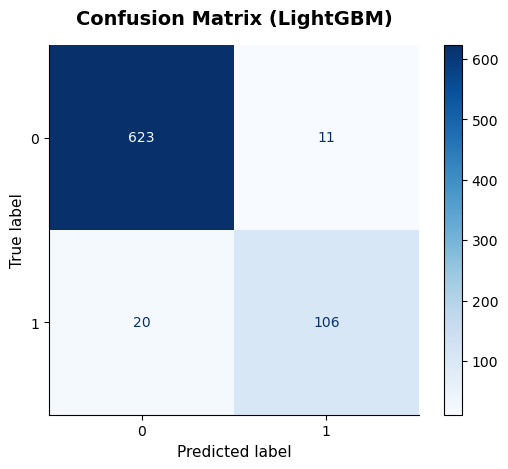

In [122]:
best_model_name =formatted_df["F1"].idxmax()  
best_model = models[best_model_name]

best_threshold = threshold_df.loc[best_model_name, "Best_Threshold"]

probs = best_model.predict_proba(X_val_final)[:, 1]
preds = (probs >= best_threshold).astype(int)

cm = confusion_matrix(y_val, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.grid(False)
plt.title(f"Confusion Matrix ({best_model_name})", fontsize=14, fontweight="bold", pad=15)
plt.show()

***

Ma trận nhầm lẫn cho thấy mô hình đạt hiệu quả phân loại khá tốt trên tập validation. Cụ thể, mô hình dự đoán đúng **623** khách hàng không churn và **106** khách hàng churn. Số trường hợp dự đoán sai tương đối thấp, chỉ gồm **11** khách hàng không churn bị dự đoán nhầm thành churn và **20** khách hàng churn bị bỏ sót.

Kết quả này cho thấy mô hình có khả năng phân biệt hai lớp khá rõ ràng, đặc biệt là ở việc hạn chế số lượng dự đoán dương tính sai. Đồng thời, mô hình vẫn giữ được khả năng phát hiện phần lớn khách hàng có nguy cơ rời bỏ. Đây là một tín hiệu tích cực đối với bài toán churn prediction, nơi việc nhận diện đúng nhóm khách hàng có nguy cơ rời bỏ có ý nghĩa quan trọng trong các quyết định giữ chân khách hàng.
***

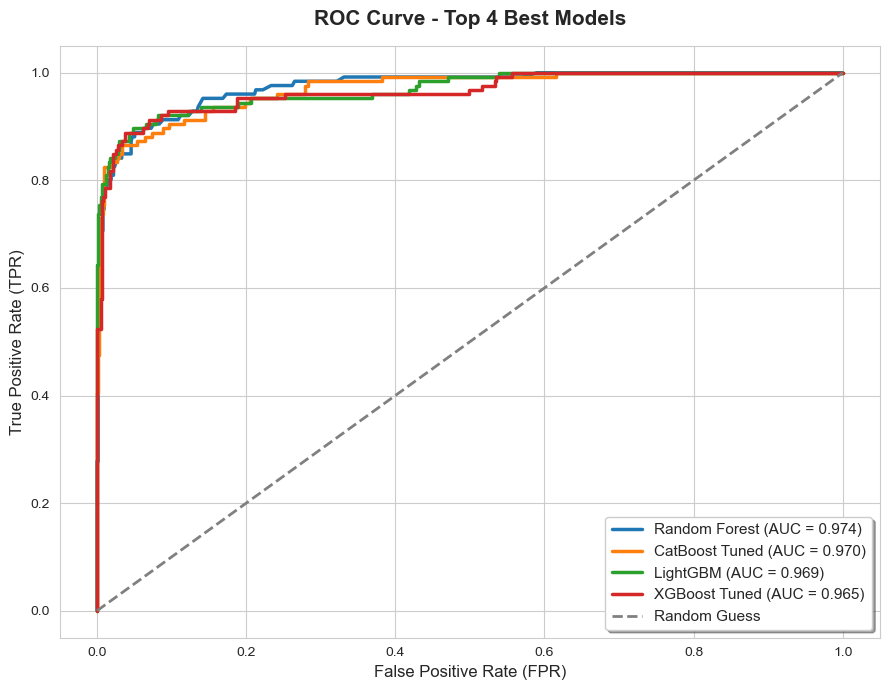

In [43]:
model_performance =[]

for name, model in models.items():
    probs = model.predict_proba(X_val_final)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = auc(fpr, tpr)
    
    # Lưu kết quả vào list tạm
    model_performance.append({
        "name": name,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc
    })

model_performance.sort(key=lambda x: x["auc"], reverse=True)

top_n = 4
top_models = model_performance[:top_n]

plt.figure(figsize=(9, 7))
sns.set_style("whitegrid") 

for item in top_models:
    plt.plot(
        item["fpr"], 
        item["tpr"], 
        linewidth=2.5, # Cho nét dày lên nhìn cho xịn
        label=f"{item['name']} (AUC = {item['auc']:.3f})"
    )

# Vẽ đường ngẫu nhiên (Random Guess)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=2, label="Random Guess")

# Tinh chỉnh text
plt.title(f"ROC Curve - Top {top_n} Best Models", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)

# Chuyển Legend xuống góc phải dưới
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

**TabNet (Default Configuration)**

In [44]:
X_train_np = X_train_final.values.astype("float32")
X_val_np   = X_val_final.values.astype("float32")

y_train_np = y_train.values
y_val_np   = y_val.values

print("Shapes for TabNet:")
print("Train:", X_train_np.shape)
print("Val:", X_val_np.shape)

Shapes for TabNet:
Train: (3546, 17)
Val: (760, 17)


In [45]:
tabnet_default = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.3,
    n_independent=2,
    n_shared=2,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=1,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":20, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type="entmax",
    verbose=1,
    seed=42
)

In [46]:
print("Training TabNet (Default Configuration)...")
start_time = time.perf_counter()

tabnet_default.fit(
    X_train_np,
    y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    eval_name=["val"],
    eval_metric=["auc"],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

# ---- End timer ----
tabnet_default_time = time.perf_counter() - start_time

# ---- Print nicely ----
print("=" * 50)
print(f"TabNet Default Training Time: {tabnet_default_time:.2f} seconds")
print(f"≈ {tabnet_default_time/60:.2f} minutes")
print("=" * 50)

Training TabNet (Default Configuration)...
epoch 0  | loss: 0.5953  | val_auc: 0.59173 |  0:00:00s
epoch 1  | loss: 0.4711  | val_auc: 0.67772 |  0:00:00s
epoch 2  | loss: 0.41875 | val_auc: 0.64579 |  0:00:01s
epoch 3  | loss: 0.41012 | val_auc: 0.6492  |  0:00:01s
epoch 4  | loss: 0.40889 | val_auc: 0.66788 |  0:00:01s
epoch 5  | loss: 0.38947 | val_auc: 0.70097 |  0:00:01s
epoch 6  | loss: 0.38546 | val_auc: 0.72495 |  0:00:02s
epoch 7  | loss: 0.38313 | val_auc: 0.74651 |  0:00:02s
epoch 8  | loss: 0.37406 | val_auc: 0.75985 |  0:00:02s
epoch 9  | loss: 0.35988 | val_auc: 0.76074 |  0:00:03s
epoch 10 | loss: 0.35543 | val_auc: 0.76709 |  0:00:03s
epoch 11 | loss: 0.35567 | val_auc: 0.76507 |  0:00:03s
epoch 12 | loss: 0.35325 | val_auc: 0.78073 |  0:00:04s
epoch 13 | loss: 0.34026 | val_auc: 0.79345 |  0:00:04s
epoch 14 | loss: 0.33636 | val_auc: 0.77961 |  0:00:04s
epoch 15 | loss: 0.33523 | val_auc: 0.78386 |  0:00:04s
epoch 16 | loss: 0.34047 | val_auc: 0.80029 |  0:00:05s
epoch

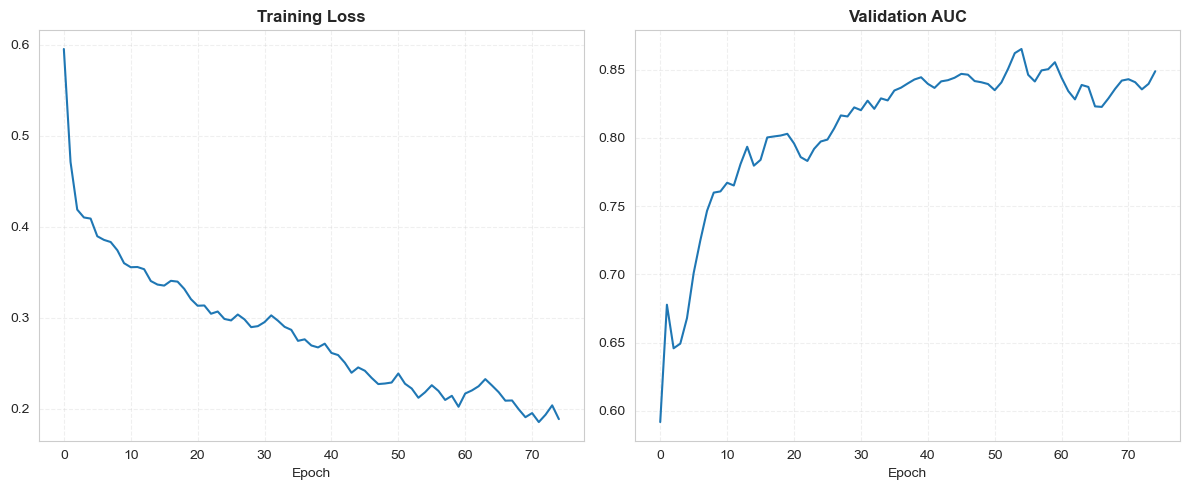

In [47]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(tabnet_default.history["loss"], label="Train Loss")
plt.title("Training Loss", fontweight="bold")
plt.xlabel("Epoch")
plt.grid(True, linestyle="--", alpha=0.3)

# Validation AUC
plt.subplot(1,2,2)
plt.plot(tabnet_default.history["val_auc"], label="Validation AUC")
plt.title("Validation AUC", fontweight="bold")
plt.xlabel("Epoch")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
tabnet_val_metrics = evaluate_model(
    tabnet_default,
    X_val_np,
    y_val_np
)

tabnet_val_metrics["Training_Time"] = tabnet_default_time

print("TabNet Default (Validation):")
print(tabnet_val_metrics)

TabNet Default (Validation):
{'F1': 0.5741626794258373, 'Recall': 0.47619047619047616, 'Precision': 0.7228915662650602, 'ROC_AUC': np.float64(0.8650918832306844), 'PR_AUC': np.float64(0.6603210244989848), 'Training_Time': 26.711756399992737}


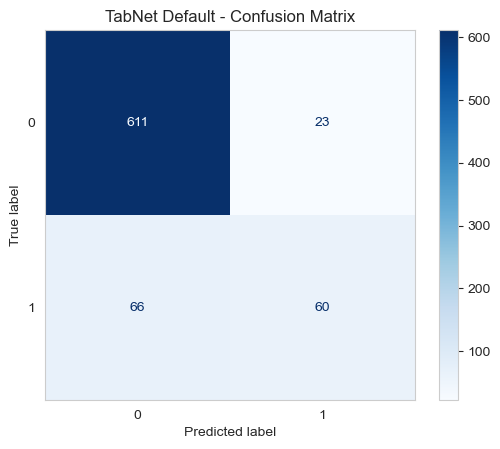

In [49]:
probs = tabnet_default.predict_proba(X_val_np)[:,1]
preds = (probs >= 0.5).astype(int)

cm = confusion_matrix(y_val_np, preds)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", values_format="d") 
plt.grid(False)
plt.title("TabNet Default - Confusion Matrix")
plt.show()

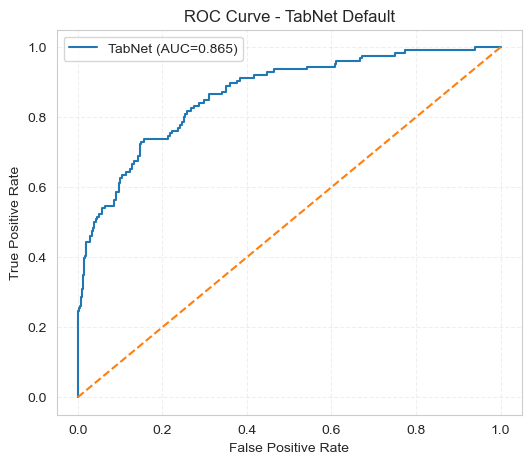

In [50]:
fpr, tpr, _ = roc_curve(y_val_np, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"TabNet (AUC={roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve - TabNet Default")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

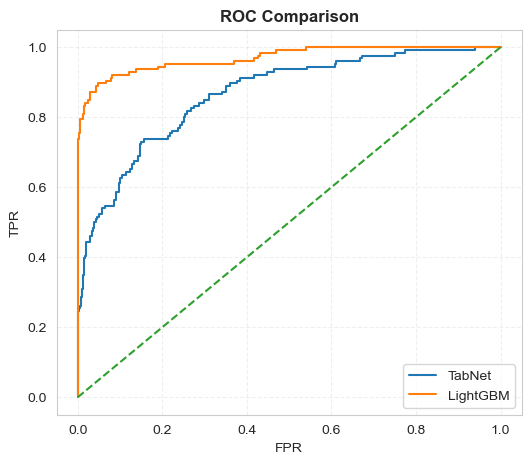

In [52]:
plt.figure(figsize=(6,5))

# TabNet
probs_tabnet = tabnet_default.predict_proba(X_val_np)[:,1]
fpr_t, tpr_t, _ = roc_curve(y_val_np, probs_tabnet)
plt.plot(fpr_t, tpr_t, label="TabNet")

# Best baseline
probs_base = lgb_model.predict_proba(X_val_final)[:,1]
fpr_b, tpr_b, _ = roc_curve(y_val, probs_base)
plt.plot(fpr_b, tpr_b, label="LightGBM")

plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Comparison", fontweight="bold")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

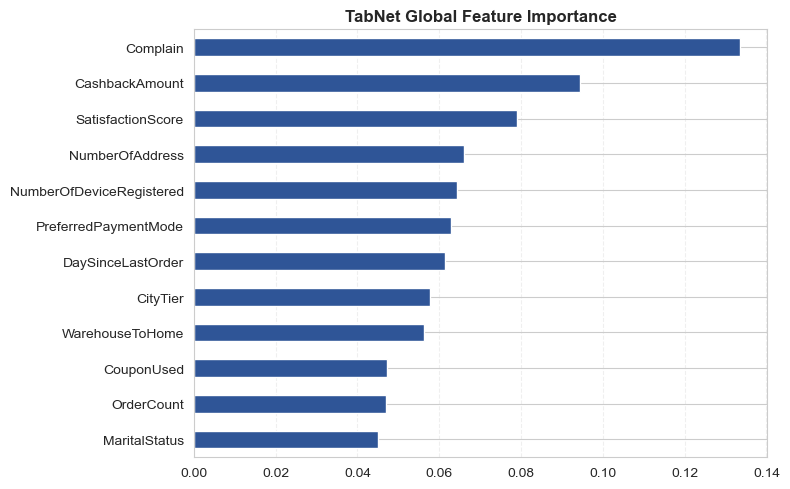

Complain                       0.133462
CashbackAmount                 0.094424
SatisfactionScore              0.078936
NumberOfAddress                0.066160
NumberOfDeviceRegistered       0.064276
PreferredPaymentMode           0.062798
DaySinceLastOrder              0.061435
CityTier                       0.057808
WarehouseToHome                0.056371
CouponUsed                     0.047288
OrderCount                     0.046953
MaritalStatus                  0.045044
HourSpendOnApp                 0.043918
OrderAmountHikeFromlastYear    0.041805
PreferedOrderCat               0.039992
dtype: float64

In [53]:
tabnet_importance = pd.Series(
    tabnet_default.feature_importances_,
    index=FINAL_COLS
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
tabnet_importance.head(12).plot(kind="barh", color="#2F5597")
plt.title("TabNet Global Feature Importance", fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

display(tabnet_importance.head(15))

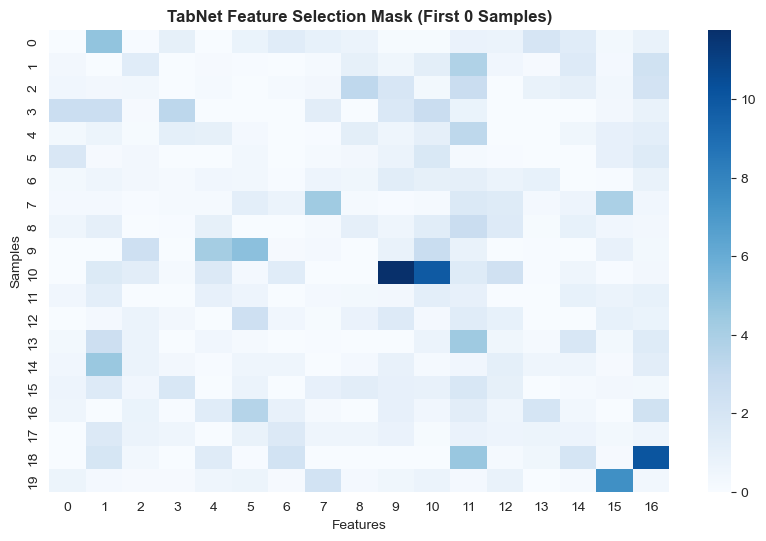

In [54]:
explain_matrix, masks = tabnet_default.explain(X_val_np)

plt.figure(figsize=(10,6))
sns.heatmap(
    explain_matrix[:20],  # lấy 50 sample cho đẹp
    cmap="Blues",
    cbar=True
)
plt.title("TabNet Feature Selection Mask (First 0 Samples)", fontweight="bold")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.show()

**TabNet + PSO Optimization**

In [55]:
np.random.seed(42)

def best_f1_threshold(y_true, y_prob):
    """Find threshold maximizing F1 on validation (important for imbalance)."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    best_idx = np.argmax(f1)
    # thresholds has length n-1 compared to precision/recall
    best_th = thresholds[max(best_idx - 1, 0)] if len(thresholds) > 0 else 0.5
    return float(best_th), float(f1[best_idx])

In [56]:
lb = np.array([  8,   3, 1.0, 1e-3, 1e-6,  256,   64, 1], dtype=float)
ub = np.array([ 64,  10, 2.0, 5e-2, 1e-3, 2048,  512, 8], dtype=float)

def decode_params(x):
    """Map a PSO particle position x to TabNet hyperparameters."""
    n_d = int(np.round(x[0]))
    n_a = n_d  # common practice: tie n_a to n_d for stable search
    
    n_steps = int(np.round(x[1]))
    gamma = float(x[2])
    lr = float(x[3])
    lambda_sparse = float(x[4])
    
    batch_size = int(np.round(x[5] / 64) * 64)          # keep multiple of 64
    virtual_batch_size = int(np.round(x[6] / 64) * 64)  # multiple of 64
    
    # Safety: virtual_batch_size <= batch_size
    virtual_batch_size = int(min(virtual_batch_size, batch_size))
    virtual_batch_size = int(max(64, virtual_batch_size))
    batch_size = int(max(256, batch_size))
    
    cat_emb_dim = int(np.round(x[7]))
    cat_emb_dim = int(np.clip(cat_emb_dim, 1, 16))
    
    # Clip ints to valid ranges
    n_d = int(np.clip(n_d, 8, 64))
    n_steps = int(np.clip(n_steps, 3, 10))
    gamma = float(np.clip(gamma, 1.0, 2.0))
    lr = float(np.clip(lr, 1e-4, 5e-2))
    lambda_sparse = float(np.clip(lambda_sparse, 1e-6, 1e-3))
    
    return dict(
        n_d=n_d, n_a=n_a, n_steps=n_steps, gamma=gamma,
        lr=lr, lambda_sparse=lambda_sparse,
        batch_size=batch_size, virtual_batch_size=virtual_batch_size,
        cat_emb_dim=cat_emb_dim
    )

In [57]:
_eval_cache = {}

def tabnet_val_f1(params, max_epochs=120, patience=20):
    key = tuple(sorted(params.items()))
    if key in _eval_cache:
        return _eval_cache[key]

    model = TabNetClassifier(
        n_d=params["n_d"],
        n_a=params["n_a"],
        n_steps=params["n_steps"],
        gamma=params["gamma"],
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        cat_emb_dim=params["cat_emb_dim"],
        lambda_sparse=params["lambda_sparse"],
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=params["lr"]),
        mask_type="entmax",
        seed=42,
        verbose=0
    )

    model.fit(
        X_train_np, y_train_np,
        eval_set=[(X_val_np, y_val_np)],
        eval_name=["val"],
        eval_metric=["auc"],
        max_epochs=max_epochs,
        patience=patience,
        batch_size=params["batch_size"],
        virtual_batch_size=params["virtual_batch_size"],
        num_workers=0,
        drop_last=False
    )

    y_prob = model.predict_proba(X_val_np)[:, 1]
    th, best_f1 = best_f1_threshold(y_val_np, y_prob)

    _eval_cache[key] = (best_f1, th, model)
    return _eval_cache[key]

In [58]:
print("Running PSO Optimization for TabNet...")

pso_start_time = time.perf_counter()
def run_pso(
    n_particles=10,
    n_iters=12,
    w=0.72, c1=1.49, c2=1.49,
    max_epochs=120, patience=20
):
    dim = len(lb)

    # Initialize particles
    X = lb + (ub - lb) * np.random.rand(n_particles, dim)
    V = np.zeros_like(X)

    pbest_X = X.copy()
    pbest_score = np.full(n_particles, -np.inf)

    gbest_X = None
    gbest_score = -np.inf
    gbest_threshold = 0.5
    gbest_params = None

    history = []

    for it in range(1, n_iters + 1):
        print(f"\n========== PSO ITERATION {it}/{n_iters} ==========")

        for i in range(n_particles):
            params = decode_params(X[i])

            # Objective: maximize F1 on validation
            f1, th, _model = tabnet_val_f1(params, max_epochs=max_epochs, patience=patience)

            print(f"Particle {i+1:02d}: F1={f1:.4f} | th={th:.3f} | {params}")

            # Update personal best
            if f1 > pbest_score[i]:
                pbest_score[i] = f1
                pbest_X[i] = X[i].copy()

            # Update global best
            if f1 > gbest_score:
                gbest_score = f1
                gbest_X = X[i].copy()
                gbest_threshold = th
                gbest_params = params

        history.append({"iter": it, "best_f1": gbest_score, "best_threshold": gbest_threshold, **gbest_params})

        # Update velocities/positions
        r1 = np.random.rand(n_particles, dim)
        r2 = np.random.rand(n_particles, dim)
        V = w * V + c1 * r1 * (pbest_X - X) + c2 * r2 * (gbest_X - X)
        X = X + V

        # Keep within bounds
        X = np.clip(X, lb, ub)

    hist_df = pd.DataFrame(history)
    return gbest_params, gbest_score, gbest_threshold, hist_df

# ---- Run PSO ----
best_params, best_f1, best_threshold, pso_history = run_pso(
    n_particles=10,
    n_iters=5,
    max_epochs=120,
    patience=20
)
if torch.cuda.is_available():
    torch.cuda.synchronize()

tabnet_pso_total_time = time.perf_counter() - pso_start_time

print("=" * 50)
print(f"TabNet + PSO Total Time: {tabnet_pso_total_time:.2f} seconds")
print(f"≈ {tabnet_pso_total_time/60:.2f} minutes")
print("Best F1 (val):", best_f1)
print("Best threshold:", best_threshold)
print("Best params:", best_params)
print("=" * 50)

display(pso_history)

Running PSO Optimization for TabNet...

========== PSO ITERATION 1/5 ==========
Stop training because you reached max_epochs = 120 with best_epoch = 114 and best_val_auc = 0.86786
Particle 01: F1=0.6214 | th=0.297 | {'n_d': 29, 'n_a': 29, 'n_steps': 10, 'gamma': 1.731993941811405, 'lr': 0.030334265725654796, 'lambda_sparse': 0.0001568626218019941, 'batch_size': 512, 'virtual_batch_size': 64, 'cat_emb_dim': 7}

Early stopping occurred at epoch 117 with best_epoch = 97 and best_val_auc = 0.96404
Particle 02: F1=0.8750 | th=0.765 | {'n_d': 42, 'n_a': 42, 'n_steps': 8, 'gamma': 1.0205844942958024, 'lr': 0.04852558275593773, 'lambda_sparse': 0.0008326101981596214, 'batch_size': 640, 'virtual_batch_size': 128, 'cat_emb_dim': 2}

Early stopping occurred at epoch 44 with best_epoch = 24 and best_val_auc = 0.81921
Particle 03: F1=0.5474 | th=0.319 | {'n_d': 25, 'n_a': 25, 'n_steps': 7, 'gamma': 1.4319450186421157, 'lr': 0.015270227869704053, 'lambda_sparse': 0.0006122410418276571, 'batch_size':

,iter,best_f1,best_threshold,n_d,n_a,n_steps,gamma,lr,lambda_sparse,batch_size,virtual_batch_size,cat_emb_dim
0,1,0.875000,0.765310,42,42,8,1.020584,0.048526,0.000833,640,128,2
1,2,0.919355,0.526695,37,37,8,1.000000,0.044668,0.000782,448,320,2
2,3,0.919355,0.526695,37,37,8,1.000000,0.044668,0.000782,448,320,2
3,4,0.929134,0.462061,38,38,9,1.000000,0.047078,0.000737,256,256,1
4,5,0.929134,0.462061,38,38,9,1.000000,0.047078,0.000737,256,256,1


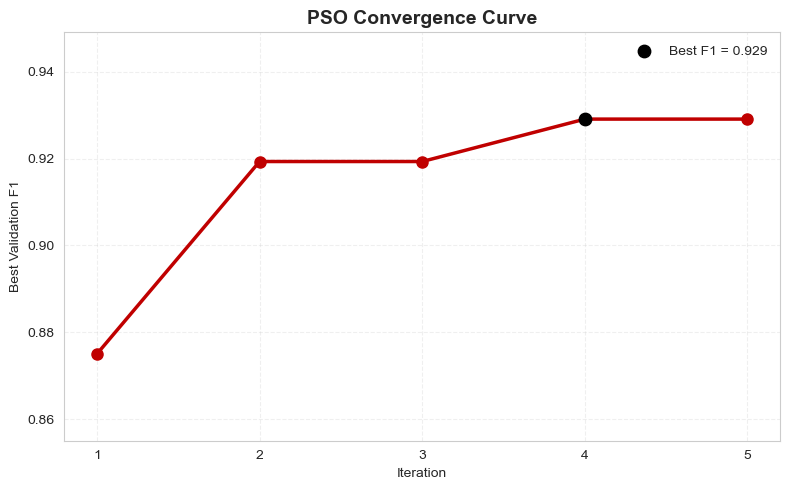

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(
    pso_history["iter"],
    pso_history["best_f1"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#C00000"
)

# highlight best point
best_idx = pso_history["best_f1"].idxmax()
best_iter = pso_history.loc[best_idx, "iter"]
best_score = pso_history.loc[best_idx, "best_f1"]

plt.scatter(
    best_iter,
    best_score,
    color="black",
    s=80,
    zorder=5,
    label=f"Best F1 = {best_score:.3f}"
)

plt.title("PSO Convergence Curve", fontweight="bold", fontsize=14)
plt.xlabel("Iteration")
plt.ylabel("Best Validation F1")
plt.ylim(
    max(0, pso_history["best_f1"].min() - 0.02),
    min(1.0, pso_history["best_f1"].max() + 0.02)
)
plt.xticks(pso_history["iter"])
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [60]:
print("Training TabNet (PSO-Optimized Configuration)...")
start_time = time.perf_counter()
final_fit_start = time.perf_counter()
tabnet_pso = TabNetClassifier(
    n_d=best_params["n_d"],
    n_a=best_params["n_a"],
    n_steps=best_params["n_steps"],
    gamma=best_params["gamma"],
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=best_params["cat_emb_dim"],
    lambda_sparse=best_params["lambda_sparse"],
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=best_params["lr"]),
    mask_type="entmax",
    seed=42,
    verbose=1
)

tabnet_pso.fit(
    X_train_np, y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    eval_name=["val"],
    eval_metric=["auc"],
    max_epochs=200,
    patience=30,
    batch_size=best_params["batch_size"],
    virtual_batch_size=best_params["virtual_batch_size"],
    num_workers=0,
    drop_last=False
)
# Evaluate with best_threshold found by PSO
val_prob = tabnet_pso.predict_proba(X_val_np)[:, 1]
val_pred = (val_prob >= best_threshold).astype(int)

tabnet_pso_val = {
    "F1": f1_score(y_val_np, val_pred),
    "Best_Threshold": best_threshold
}

print("\nTabNet + PSO (Validation):", tabnet_pso_val)

if torch.cuda.is_available():
    torch.cuda.synchronize()

tabnet_pso_fit_time = time.perf_counter() - final_fit_start

print("=" * 50)
print(f"TabNet + PSO Final Fit Time: {tabnet_pso_fit_time:.2f} seconds")
print(f"≈ {tabnet_pso_fit_time/60:.2f} minutes")
print("=" * 50)

Training TabNet (PSO-Optimized Configuration)...
epoch 0  | loss: 0.84932 | val_auc: 0.56863 |  0:00:01s
epoch 1  | loss: 0.49938 | val_auc: 0.5969  |  0:00:02s
epoch 2  | loss: 0.3814  | val_auc: 0.68019 |  0:00:03s
epoch 3  | loss: 0.36384 | val_auc: 0.70818 |  0:00:03s
epoch 4  | loss: 0.34353 | val_auc: 0.73798 |  0:00:04s
epoch 5  | loss: 0.34782 | val_auc: 0.75392 |  0:00:05s
epoch 6  | loss: 0.34096 | val_auc: 0.77813 |  0:00:06s
epoch 7  | loss: 0.3473  | val_auc: 0.80372 |  0:00:07s
epoch 8  | loss: 0.33019 | val_auc: 0.81025 |  0:00:08s
epoch 9  | loss: 0.3188  | val_auc: 0.8095  |  0:00:09s
epoch 10 | loss: 0.30812 | val_auc: 0.80926 |  0:00:10s
epoch 11 | loss: 0.30795 | val_auc: 0.79681 |  0:00:11s
epoch 12 | loss: 0.29082 | val_auc: 0.8015  |  0:00:12s
epoch 13 | loss: 0.2813  | val_auc: 0.80447 |  0:00:13s
epoch 14 | loss: 0.26722 | val_auc: 0.83084 |  0:00:14s
epoch 15 | loss: 0.27917 | val_auc: 0.81432 |  0:00:15s
epoch 16 | loss: 0.28329 | val_auc: 0.80782 |  0:00:16s

In [61]:
tabnet_pso_val_metrics = evaluate_model(
    tabnet_pso,
    X_val_np,
    y_val_np,
    threshold=best_threshold
)

tabnet_pso_val_metrics["Training_Time"] = tabnet_pso_total_time

print("TabNet + PSO (Validation):")
print(tabnet_pso_val_metrics)

TabNet + PSO (Validation):
{'F1': 0.9254901960784314, 'Recall': 0.9365079365079365, 'Precision': 0.9147286821705426, 'ROC_AUC': np.float64(0.9797706674678284), 'PR_AUC': np.float64(0.9458469125453847), 'Training_Time': 4013.823966099997}


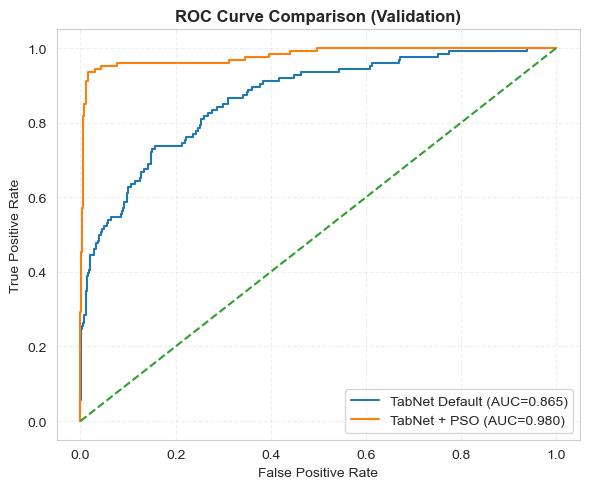

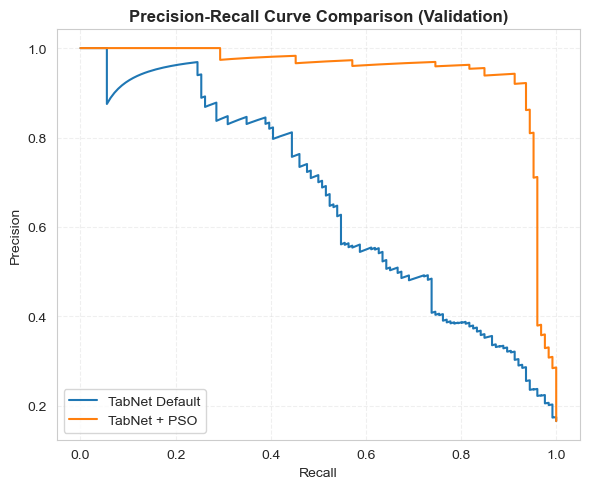

In [62]:
# TabNet default probs
prob_def = tabnet_default.predict_proba(X_val_np)[:, 1]
# TabNet PSO probs
prob_pso = tabnet_pso.predict_proba(X_val_np)[:, 1]

# ROC
plt.figure(figsize=(6,5))
for name, prob in [("TabNet Default", prob_def), ("TabNet + PSO", prob_pso)]:
    fpr, tpr, _ = roc_curve(y_val_np, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve Comparison (Validation)", fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# PR
plt.figure(figsize=(6,5))
for name, prob in [("TabNet Default", prob_def), ("TabNet + PSO", prob_pso)]:
    prec, rec, _ = precision_recall_curve(y_val_np, prob)
    plt.plot(rec, prec, label=name)

plt.title("Precision-Recall Curve Comparison (Validation)", fontweight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

***
The results of hyperparameter optimization using PSO show a clear improvement in TabNet performance compared to the default configuration, particularly in terms of F1-score, which is well-suited for imbalanced data.

The PSO convergence curve demonstrates a gradual stabilization over iterations, reflecting the algorithm’s effectiveness in exploring the hyperparameter space.

Additionally, the ROC and PR curves indicate that the TabNet + PSO model improves class discrimination and/or achieves a better precision–recall balance compared to the default TabNet. This further supports the effectiveness of combining metaheuristic optimization with deep learning architectures for tabular data.
***

**Final Evaluation on TEST SET**

In [63]:
final_model = tabnet_pso
final_threshold = best_threshold

In [64]:
X_test_np = X_test_final.values.astype("float32")
y_test_np = y_test.values

test_prob = final_model.predict_proba(X_test_np)[:,1]
test_pred = (test_prob >= final_threshold).astype(int)

In [65]:
final_results = {
    "F1": f1_score(y_test_np, test_pred),
    "Recall": recall_score(y_test_np, test_pred),
    "Precision": precision_score(y_test_np, test_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test_np, test_prob),
    "PR_AUC": average_precision_score(y_test_np, test_prob),
    "Training_Time": tabnet_pso_total_time
}

print("FINAL TEST RESULTS — TabNet + PSO")
print(final_results)

FINAL TEST RESULTS — TabNet + PSO
{'F1': 0.890625, 'Recall': 0.9047619047619048, 'Precision': 0.8769230769230769, 'ROC_AUC': np.float64(0.9792275965504311), 'PR_AUC': np.float64(0.8994191938777691), 'Training_Time': 4013.823966099997}


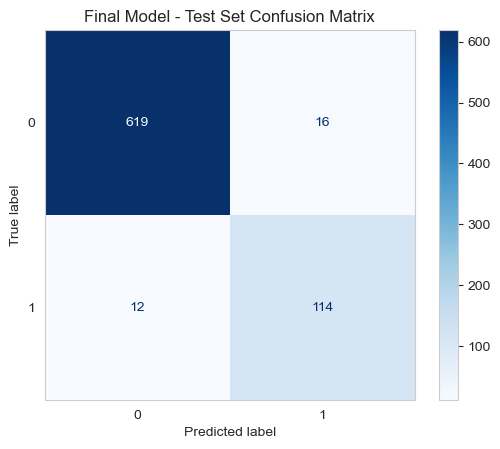

In [67]:
cm = confusion_matrix(y_test_np, test_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Final Model - Test Set Confusion Matrix")
plt.grid(False)
plt.show()

In [68]:
def best_f1_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)

    # thresholds shorter than precision/recall by 1
    best_idx = np.argmax(f1_scores[:-1]) if len(thresholds) > 0 else 0
    best_th = thresholds[best_idx] if len(thresholds) > 0 else 0.5
    best_f1 = f1_scores[best_idx]

    return float(best_th), float(best_f1)

# TabNet Default threshold on validation
tabnet_default_probs = tabnet_default.predict_proba(X_val_np)[:, 1]
tabnet_default_th, tabnet_default_best_f1 = best_f1_threshold(y_val_np, tabnet_default_probs)

# TabNet + PSO threshold on validation
tabnet_pso_probs = tabnet_pso.predict_proba(X_val_np)[:, 1]
tabnet_pso_th, tabnet_pso_best_f1 = best_f1_threshold(y_val_np, tabnet_pso_probs)

threshold_df.loc["TabNet Default"] = {
    "Best_Threshold": tabnet_default_th,
    "Best_F1": tabnet_default_best_f1
}

threshold_df.loc["TabNet + PSO"] = {
    "Best_Threshold": tabnet_pso_th,
    "Best_F1": tabnet_pso_best_f1
}

display(threshold_df)

,Best_Threshold,Best_F1
Logistic Regression,0.650660,0.552448
Random Forest,0.404000,0.857143
XGBoost,0.435394,0.854839
XGBoost Tuned,0.268911,0.866397
MLP,0.272447,0.803150
LightGBM,0.262603,0.872428
CatBoost,0.440052,0.828829
CatBoost Tuned,0.340881,0.881356
TabNet Default,0.440310,0.590909
TabNet + PSO,0.523261,0.929134


In [69]:
tabnet_rows = {}

# -------------------------
# TabNet Default
# -------------------------
tabnet_default_threshold = 0.5
if "TabNet Default" in threshold_df.index:
    tabnet_default_threshold = threshold_df.loc["TabNet Default", "Best_Threshold"]

tabnet_default_metrics = evaluate_model(
    tabnet_default,
    X_test_np,
    y_test_np,
    threshold=tabnet_default_threshold
)

tabnet_rows["TabNet Default"] = {
    "CV_F1_Mean": np.nan,   # no CV for TabNet
    "CV_F1_Std": np.nan,    # no CV for TabNet
    "F1": tabnet_default_metrics["F1"],
    "Recall": tabnet_default_metrics["Recall"],
    "Precision": tabnet_default_metrics["Precision"],
    "ROC_AUC": tabnet_default_metrics["ROC_AUC"],
    "PR_AUC": tabnet_default_metrics["PR_AUC"],
    "Training_Time": tabnet_default_time,
    "Best_Threshold": tabnet_default_threshold
}

# -------------------------
# TabNet + PSO
# -------------------------
tabnet_pso_threshold = 0.5
if "TabNet + PSO" in threshold_df.index:
    tabnet_pso_threshold = threshold_df.loc["TabNet + PSO", "Best_Threshold"]
elif "best_threshold" in globals():
    tabnet_pso_threshold = best_threshold

tabnet_pso_metrics = evaluate_model(
    tabnet_pso,
    X_test_np,
    y_test_np,
    threshold=tabnet_pso_threshold
)

tabnet_rows["TabNet + PSO"] = {
    "CV_F1_Mean": np.nan,   # no CV for TabNet + PSO
    "CV_F1_Std": np.nan,    # no CV for TabNet + PSO
    "F1": tabnet_pso_metrics["F1"],
    "Recall": tabnet_pso_metrics["Recall"],
    "Precision": tabnet_pso_metrics["Precision"],
    "ROC_AUC": tabnet_pso_metrics["ROC_AUC"],
    "PR_AUC": tabnet_pso_metrics["PR_AUC"],
    "Training_Time": tabnet_pso_total_time,
    "Best_Threshold": tabnet_pso_threshold
}

tabnet_df = pd.DataFrame(tabnet_rows).T


final_table = pd.concat([comparison_df, tabnet_df], axis=0)

final_table = final_table[
    [
        "CV_F1_Mean",
        "CV_F1_Std",
        "F1",
        "Recall",
        "Precision",
        "ROC_AUC",
        "PR_AUC",
        "Training_Time",
        "Best_Threshold"
    ]
].sort_values("F1", ascending=False)

display(final_table)

,CV_F1_Mean,CV_F1_Std,F1,Recall,Precision,ROC_AUC,PR_AUC,Training_Time,Best_Threshold
TabNet + PSO,NaN,NaN,0.894118,0.904762,0.883721,0.979228,0.899419,4013.823966,0.523261
LightGBM,0.771225,0.041114,0.854626,0.769841,0.960396,0.968842,0.929419,0.347485,0.262603
XGBoost Tuned,0.762798,0.034306,0.843478,0.769841,0.932692,0.965412,0.918012,0.804152,0.268911
XGBoost,0.773317,0.026280,0.842975,0.809524,0.879310,0.961544,0.904927,0.721894,0.435394
CatBoost Tuned,0.780493,0.032694,0.840708,0.753968,0.950000,0.969931,0.917817,1.807842,0.340881
CatBoost,0.748421,0.038097,0.807339,0.698413,0.956522,0.956575,0.890378,1.523888,0.440052
Random Forest,0.704471,0.066052,0.788732,0.666667,0.965517,0.973962,0.918648,1.303656,0.404000
MLP,0.712252,0.047472,0.776860,0.746032,0.810345,0.929235,0.789770,4.330066,0.272447
Logistic Regression,0.474095,0.019206,0.500000,0.769841,0.370229,0.819275,0.539262,0.011338,0.650660
TabNet Default,NaN,NaN,0.477064,0.412698,0.565217,0.820835,0.514503,26.711756,0.440310


**Lưu ý:** Giá trị **NaN** tại các cột **CV_F1_Mean** và **CV_F1_Std** của **TabNet Default** và **TabNet + PSO** xuất hiện do nghiên cứu **không thực hiện cross-validation** cho hai mô hình này, nhằm tránh chi phí tính toán quá lớn. Vì vậy, đây là trường hợp **không tính toán**, không phải lỗi dữ liệu.

***
Bảng kết quả cho thấy các mô hình trong nghiên cứu có sự khác biệt khá rõ về hiệu quả dự đoán, độ ổn định và chi phí huấn luyện.

Trước hết, các giá trị **NaN** tại hai cột **CV_F1_Mean** và **CV_F1_Std** của **TabNet Default** và **TabNet + PSO** không phải do lỗi dữ liệu hay lỗi mô hình, mà xuất phát từ việc **nghiên cứu không thực hiện cross-validation cho hai mô hình này**. Nguyên nhân chủ yếu là vì TabNet có thời gian huấn luyện rất lớn, đặc biệt khi kết hợp thêm bước **tối ưu siêu tham số bằng PSO**. Do đó, hai mô hình này được đánh giá trực tiếp trên tập validation thay vì huấn luyện lặp lại qua nhiều fold như các mô hình cơ sở. Vì vậy, **NaN ở đây chỉ mang ý nghĩa là không tính toán**, không phải thiếu dữ liệu.

Xét theo **chỉ số chính là F1-score**, **TabNet + PSO** là mô hình cho kết quả tốt nhất với **F1 = 0,894118**. Đồng thời, mô hình này cũng đạt **Recall = 0,904762**, **ROC-AUC = 0,979228** và **Precision = 0,883721**. Kết quả này cho thấy sau khi được tối ưu bằng PSO, TabNet có khả năng nhận diện khách hàng churn rất tốt và đạt hiệu quả tổng thể cao nhất trong số các mô hình được so sánh. Nếu mục tiêu của nghiên cứu là tối đa hóa khả năng dự đoán churn theo **F1-score**, thì **TabNet + PSO có thể xem là mô hình tốt nhất** trong bảng kết quả hiện tại.

Tuy nhiên, nếu xét ở góc độ hiệu quả thực thi và tính thực dụng, **LightGBM** cũng là một mô hình rất đáng chú ý. LightGBM đạt **F1 = 0,854626**, thấp hơn TabNet + PSO nhưng vẫn ở mức cao, đồng thời có **PR-AUC = 0,929419** cao nhất trong bảng và thời gian huấn luyện chỉ khoảng **0,347 giây**. Điều này cho thấy LightGBM mang lại sự cân bằng rất tốt giữa hiệu năng dự đoán và chi phí tính toán, đặc biệt phù hợp nếu doanh nghiệp cần một mô hình mạnh nhưng triển khai nhanh và tiết kiệm tài nguyên.

Các mô hình boosting khác như **XGBoost Tuned**, **XGBoost** và **CatBoost Tuned** cũng cho kết quả khá cạnh tranh, với **F1** dao động từ khoảng **0,84 đến 0,843**. Trong đó, **CatBoost Tuned** có **CV_F1_Mean = 0,780493** cao nhất trong nhóm mô hình có chạy cross-validation, cho thấy độ ổn định khá tốt trên các fold dữ liệu khác nhau. Dù vậy, các mô hình này vẫn thấp hơn TabNet + PSO về F1-score.

Ở nhóm còn lại, **Random Forest** đạt **ROC-AUC = 0,973962** và **Precision = 0,965517**, cho thấy khả năng phân biệt lớp và độ chính xác khi dự đoán churn khá tốt, nhưng **Recall = 0,666667** và **F1 = 0,788732** thấp hơn nhóm boosting. **MLP** cho kết quả ở mức trung bình với **F1 = 0,776860**, trong khi **Logistic Regression** và đặc biệt là **TabNet Default** cho hiệu quả thấp hơn rõ rệt. Riêng **TabNet Default** chỉ đạt **F1 = 0,477064**, cho thấy việc tối ưu siêu tham số có tác động rất lớn đến hiệu quả của kiến trúc TabNet trong bài toán này.

Từ các kết quả trên, có thể rút ra hai kết luận quan trọng. Thứ nhất, nếu xét theo **hiệu quả dự đoán cao nhất**, **TabNet + PSO là mô hình tốt nhất** trong nghiên cứu này. Thứ hai, nếu xét theo tiêu chí **cân bằng giữa hiệu năng và thời gian huấn luyện**, thì **LightGBM là mô hình cơ sở mạnh nhất và thực tế nhất**. Điều này cho thấy PSO đã giúp cải thiện đáng kể hiệu quả của TabNet, nhưng đồng thời cũng đi kèm với chi phí tính toán rất lớn.

Vì vậy, trong phạm vi nghiên cứu này, **TabNet + PSO được lựa chọn là mô hình cuối cùng** do đạt kết quả tốt nhất theo chỉ số mục tiêu **F1-score**. Trong khi đó, **LightGBM** có thể được xem là mô hình đối chứng mạnh nhất và là lựa chọn phù hợp hơn nếu ưu tiên tốc độ huấn luyện và khả năng triển khai thực tế.
***

In [3]:
comparison_table = pd.DataFrame([
    {
        "Scenario": "Keep duplicate profiles",
        "Rows": 5630,
        "Profile+Target Overlap Train-Val": 113,
        "Profile+Target Overlap Train-Test": 125,
        "Profile+Target Overlap Val-Test": 33,
        "F1": 0.8559,
        "Recall": 0.8253,
        "Precision": 0.8888,
        "ROC_AUC": 0.9748,
        "Comment": "Có overlap lớn giữa các tập dữ liệu, kết quả có thể bị lạc quan"
    },
    {
        "Scenario": "Remove duplicate profiles",
        "Rows": 5067,
        "Profile+Target Overlap Train-Val": 0,
        "Profile+Target Overlap Train-Test": 1,
        "Profile+Target Overlap Val-Test": 0,
        "F1": 0.8941,
        "Recall": 0.9047,
        "Precision": 0.8837,
        "ROC_AUC": 0.9792,
        "Comment": "Giảm overlap đáng kể, kết quả phản ánh tốt hơn khả năng tổng quát hóa"
    }
])

formatted_table = comparison_table.copy()
for col in ["F1", "Recall", "Precision", "ROC_AUC"]:
    formatted_table[col] = formatted_table[col].map(lambda x: f"{x:.4f}")

display(
    formatted_table.style
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("padding", "6px")]}
    ])
)

,Scenario,Rows,Profile+Target Overlap Train-Val,Profile+Target Overlap Train-Test,Profile+Target Overlap Val-Test,F1,Recall,Precision,ROC_AUC,Comment
0,Keep duplicate profiles,5630,113,125,33,0.8559,0.8253,0.8888,0.9748,"Có overlap lớn giữa các tập dữ liệu, kết quả có thể bị lạc quan"
1,Remove duplicate profiles,5067,0,1,0,0.8941,0.9047,0.8837,0.9792,"Giảm overlap đáng kể, kết quả phản ánh tốt hơn khả năng tổng quát hóa"


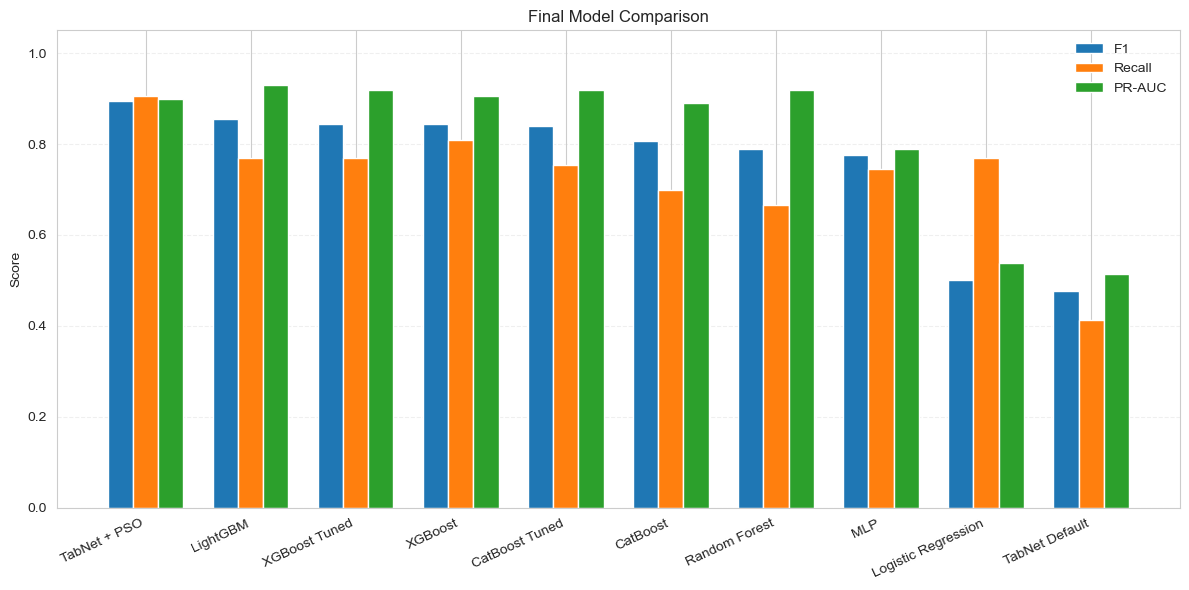

In [70]:
plot_df = final_table.copy()

plot_df = plot_df.sort_values("F1", ascending=False)

metrics_to_plot = ["F1", "Recall", "PR_AUC"]
x = np.arange(len(plot_df.index))
width = 0.24

plt.figure(figsize=(12, 6))

plt.bar(x - width, plot_df["F1"], width=width, label="F1")
plt.bar(x, plot_df["Recall"], width=width, label="Recall")
plt.bar(x + width, plot_df["PR_AUC"], width=width, label="PR-AUC")

plt.xticks(x, plot_df.index, rotation=25, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Final Model Comparison")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [71]:
test_prob = tabnet_pso.predict_proba(X_test_np)[:, 1]

lift_df = pd.DataFrame({
    "y_true": y_test_np,
    "prob": test_prob
})

lift_df = lift_df.sort_values("prob", ascending=False).reset_index(drop=True)

lift_df["population_pct"] = (np.arange(len(lift_df)) + 1) / len(lift_df) * 100

lift_df["cum_churn"] = lift_df["y_true"].cumsum()
total_churn = lift_df["y_true"].sum()

lift_df["cum_churn_capture_pct"] = lift_df["cum_churn"] / total_churn * 100

top20_cutoff = int(len(lift_df) * 0.2)
top20_capture = lift_df.iloc[top20_cutoff - 1]["cum_churn_capture_pct"]

print(f"Top 20% predicted-risk customers contain {top20_capture:.2f}% of actual churners.")

Top 20% predicted-risk customers contain 92.86% of actual churners.


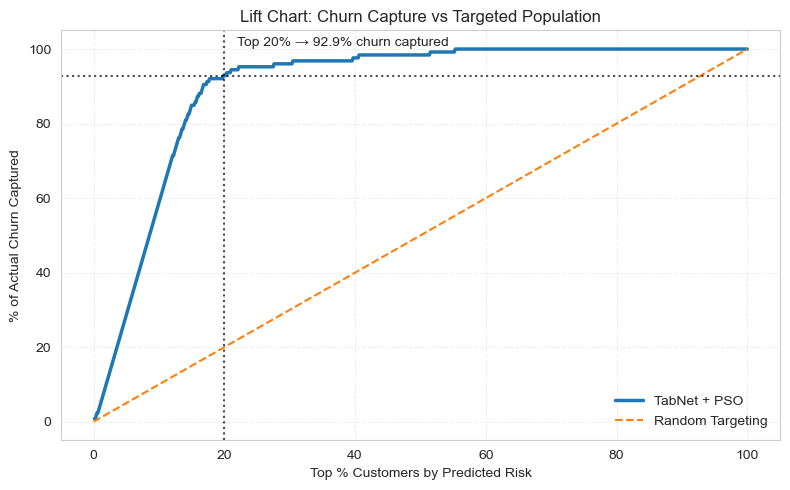

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(
    lift_df["population_pct"],
    lift_df["cum_churn_capture_pct"],
    linewidth=2.5,
    label="TabNet + PSO"
)

plt.plot([0, 100], [0, 100], linestyle="--", label="Random Targeting")

plt.axvline(x=20, linestyle=":", color="black", alpha=0.7)
plt.axhline(y=top20_capture, linestyle=":", color="black", alpha=0.7)

plt.text(22, top20_capture + 8, f"Top 20% → {top20_capture:.1f}% churn captured")

plt.title("Lift Chart: Churn Capture vs Targeted Population")
plt.xlabel("Top % Customers by Predicted Risk")
plt.ylabel("% of Actual Churn Captured")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

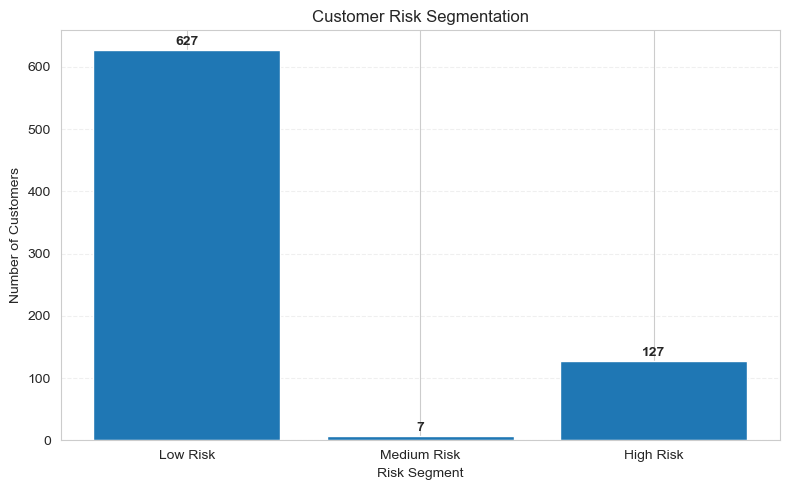

In [76]:
risk_df = pd.DataFrame({
    "prob": test_prob,
    "actual_churn": y_test_np
})

risk_df["Risk_Segment"] = pd.cut(
    risk_df["prob"],
    bins=[0, 0.3, 0.7, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

segment_counts = risk_df["Risk_Segment"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    segment_counts.index,
    segment_counts.values,
)

plt.title("Customer Risk Segmentation")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3,
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [77]:
segment_summary = risk_df.groupby("Risk_Segment", observed=False)["actual_churn"].agg(["count", "mean"])
segment_summary["Churn Rate (%)"] = segment_summary["mean"] * 100
display(segment_summary)

,count,mean,Churn Rate (%)
Risk_Segment,,,
Low Risk,627,0.017544,1.754386
Medium Risk,7,0.285714,28.571429
High Risk,127,0.889764,88.976378


In [78]:
managerial_df = pd.DataFrame({
    "Risk Segment": ["Low Risk", "Medium Risk", "High Risk"],
    "Suggested Action": [
        "Maintain loyalty and regular engagement",
        "Targeted promotions and personalized reminders",
        "Immediate retention campaign and proactive outreach"
    ]
})

display(managerial_df)

,Risk Segment,Suggested Action
0,Low Risk,Maintain loyalty and regular engagement
1,Medium Risk,Targeted promotions and personalized reminders
2,High Risk,Immediate retention campaign and proactive out...


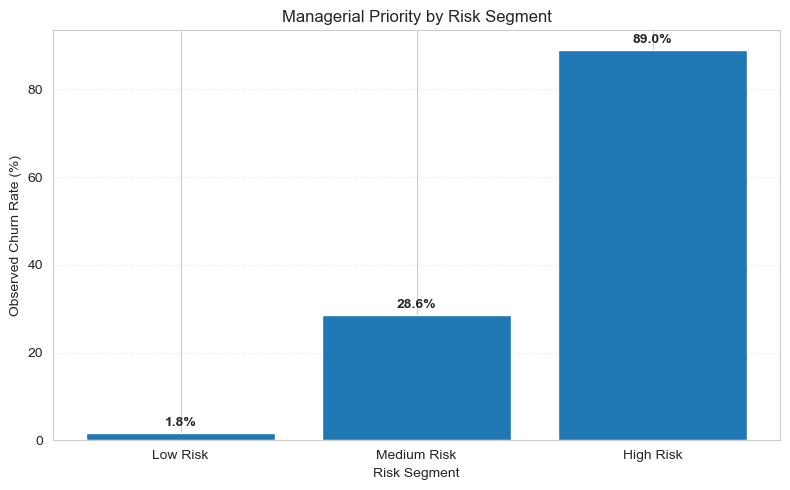

In [79]:
segment_plot = segment_summary.reset_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    segment_plot["Risk_Segment"].astype(str),
    segment_plot["Churn Rate (%)"]
)

plt.title("Managerial Priority by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Observed Churn Rate (%)")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

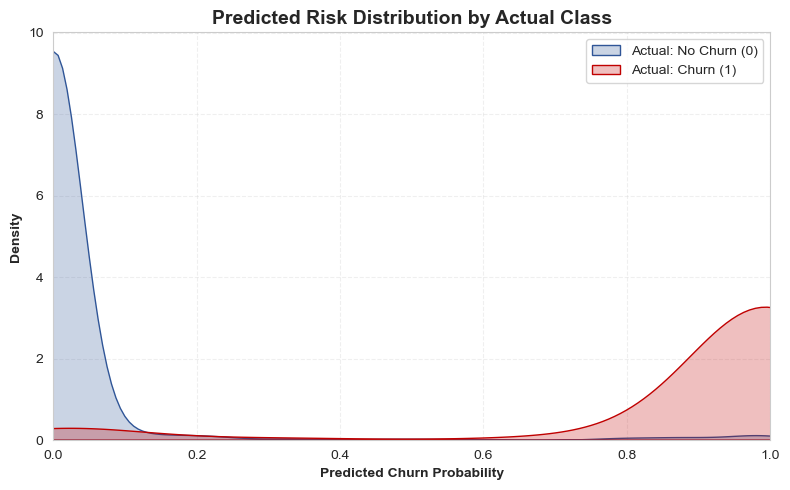

In [80]:
probs = tabnet_pso.predict_proba(X_test_np)[:, 1]

y_true = np.asarray(y_test_np).ravel()

# Kiểm tra khớp số dòng
assert len(probs) == len(y_true), f"Length mismatch: probs={len(probs)}, y_true={len(y_true)}"

plt.figure(figsize=(8, 5))

# Tách xác suất theo lớp thực tế
sns.kdeplot(
    x=probs[y_true == 0],
    fill=True,
    color="#2F5597",
    label="Actual: No Churn (0)"
)

sns.kdeplot(
    x=probs[y_true == 1],
    fill=True,
    color="#C00000",
    label="Actual: Churn (1)"
)

plt.xlabel("Predicted Churn Probability", fontweight="bold")
plt.ylabel("Density", fontweight="bold")
plt.title("Predicted Risk Distribution by Actual Class", fontweight="bold", fontsize=14)
plt.legend()
plt.xlim(0, 1)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

***
Biểu đồ cho thấy xác suất churn mà mô hình dự đoán có sự phân tách khá rõ giữa hai nhóm khách hàng thực tế.

Cụ thể, nhóm **không churn (Actual = 0)** tập trung rất mạnh ở vùng xác suất gần **0**, cho thấy mô hình gán mức rủi ro thấp cho phần lớn khách hàng thực sự không rời bỏ. Trong khi đó, nhóm **churn (Actual = 1)** lại tập trung nhiều hơn ở vùng xác suất cao, đặc biệt từ khoảng **0,8 đến 1,0**. Điều này cho thấy mô hình có khả năng gán mức rủi ro cao cho phần lớn các trường hợp rời bỏ thực tế.

Mức độ chồng lấn giữa hai phân phối là khá nhỏ. Đây là tín hiệu tích cực, vì nó cho thấy mô hình có khả năng phân biệt tương đối tốt giữa khách hàng churn và không churn. Kết quả này cũng phù hợp với các chỉ số đánh giá trước đó như **ROC-AUC**, **PR-AUC** và **F1-score**.

Biểu đồ này cho thấy mô hình không chỉ đưa ra dự đoán nhị phân, mà còn tạo ra các mức xác suất có ý nghĩa trong việc xếp hạng rủi ro khách hàng. Đây là cơ sở quan trọng để doanh nghiệp phân nhóm khách hàng theo mức độ rủi ro và ưu tiên các hoạt động giữ chân phù hợp.
***

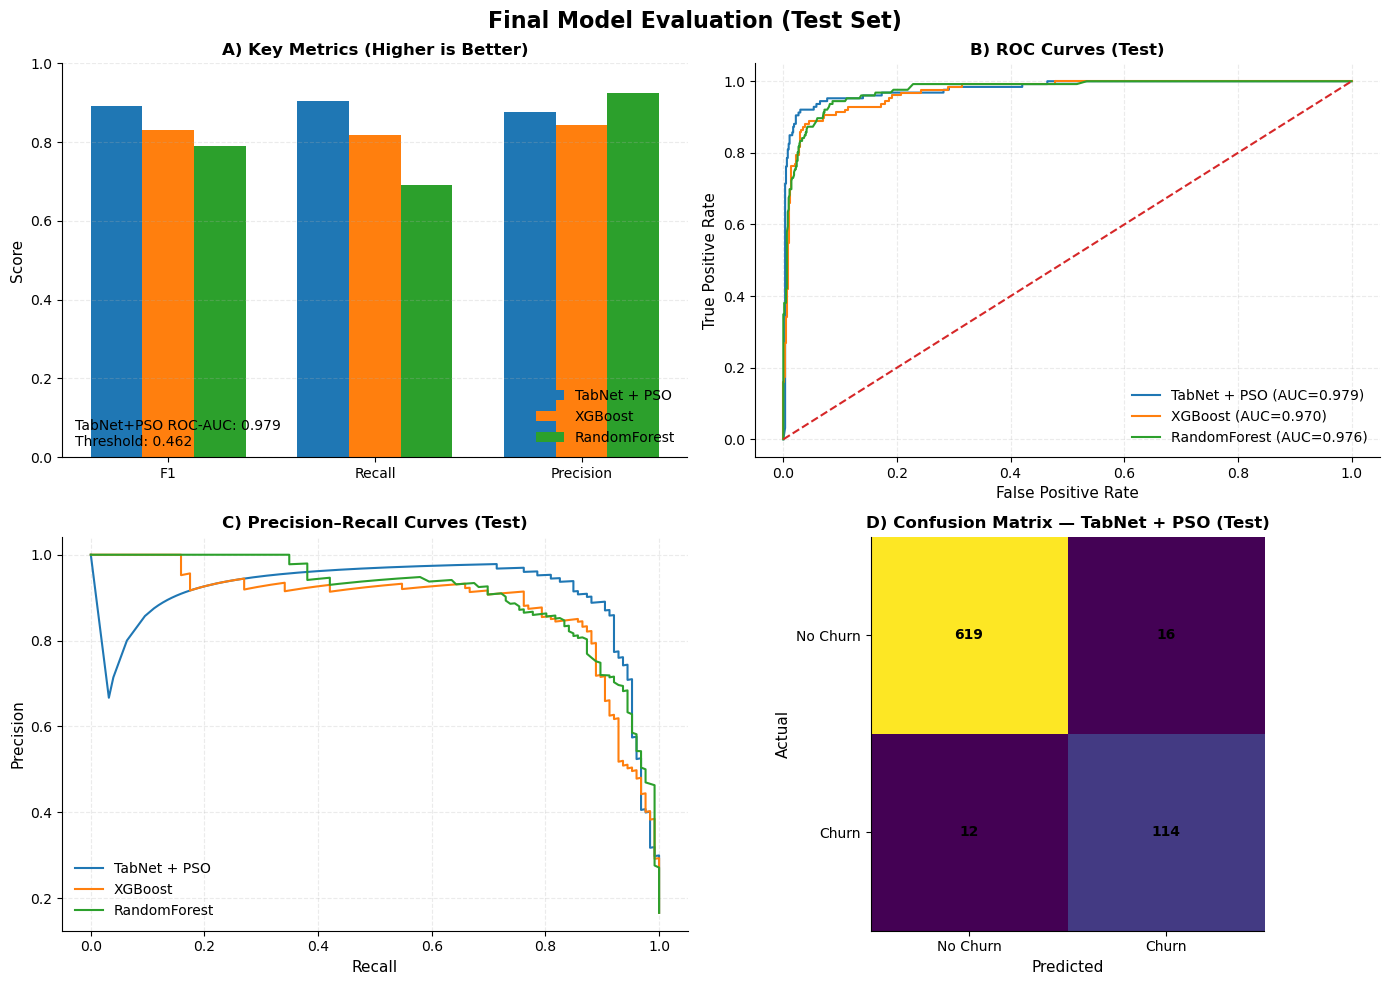

In [81]:
X_test_np = X_test_final.values.astype("float32")
y_test_np = y_test.values

def get_proba(model, X_df, X_np=None):
    """Return positive-class probabilities for both sklearn & TabNet."""
    # TabNet has predict_proba too, but expects numpy float32.
    if X_np is not None and model.__class__.__name__.lower().startswith("tabnet"):
        return model.predict_proba(X_np)[:, 1]
    return model.predict_proba(X_df)[:, 1]

# Probabilities on TEST
proba_pso = get_proba(tabnet_pso, X_test_final, X_test_np)
proba_xgb = get_proba(xgb_model,   X_test_final)
proba_rf  = get_proba(rf_model,    X_test_final)

# -------- Panel A: Model performance table -> bar chart
# Use YOUR final_table if you already built it; otherwise build a small one here:
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score

def metrics_from_proba(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        "F1": f1_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "ROC_AUC": roc_auc_score(y_true, proba)
    }

m_pso = metrics_from_proba(y_test_np, proba_pso, threshold=best_threshold)
m_xgb = metrics_from_proba(y_test_np, proba_xgb, threshold=0.5)
m_rf  = metrics_from_proba(y_test_np, proba_rf,  threshold=0.5)

perf_df = pd.DataFrame(
    {"TabNet + PSO": m_pso, "XGBoost": m_xgb, "RandomForest": m_rf}
).T

# -------- Curves
def roc_points(y_true, proba):
    fpr, tpr, _ = roc_curve(y_true, proba)
    return fpr, tpr, auc(fpr, tpr)

def pr_points(y_true, proba):
    prec, rec, _ = precision_recall_curve(y_true, proba)
    return rec, prec  # plot Recall on x, Precision on y

fpr_pso, tpr_pso, auc_pso = roc_points(y_test_np, proba_pso)
fpr_xgb, tpr_xgb, auc_xgb = roc_points(y_test_np, proba_xgb)
fpr_rf,  tpr_rf,  auc_rf  = roc_points(y_test_np, proba_rf)

rec_pso, prec_pso = pr_points(y_test_np, proba_pso)
rec_xgb, prec_xgb = pr_points(y_test_np, proba_xgb)
rec_rf,  prec_rf  = pr_points(y_test_np, proba_rf)

# -------- Confusion Matrix (best model, best threshold)
pred_pso = (proba_pso >= best_threshold).astype(int)
cm = confusion_matrix(y_test_np, pred_pso)

# -----------------------------
# ONE FIGURE DASHBOARD (2x2)
# -----------------------------
plt.style.use("default")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Final Model Evaluation (Test Set)", fontsize=16, fontweight="bold", y=0.98)

# ---- A) Performance bars (F1/Recall/Precision)
ax = axs[0, 0]
metrics_to_plot = ["F1", "Recall", "Precision"]
x = np.arange(len(metrics_to_plot))
w = 0.25

ax.bar(x - w, perf_df.loc["TabNet + PSO", metrics_to_plot].values, width=w, label="TabNet + PSO")
ax.bar(x,     perf_df.loc["XGBoost",     metrics_to_plot].values, width=w, label="XGBoost")
ax.bar(x + w, perf_df.loc["RandomForest",metrics_to_plot].values, width=w, label="RandomForest")

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.0)
ax.set_title("A) Key Metrics (Higher is Better)")
ax.set_ylabel("Score")
ax.grid(True, axis="y", linestyle="--", alpha=0.25)
ax.legend(frameon=False, loc="lower right")

# Add small text for ROC-AUC of best model
ax.text(0.02, 0.02, f"TabNet+PSO ROC-AUC: {m_pso['ROC_AUC']:.3f}\nThreshold: {best_threshold:.3f}",
        transform=ax.transAxes, fontsize=10, va="bottom")

# ---- B) ROC curves
ax = axs[0, 1]
ax.plot(fpr_pso, tpr_pso, label=f"TabNet + PSO (AUC={auc_pso:.3f})")
ax.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})")
ax.plot(fpr_rf,  tpr_rf,  label=f"RandomForest (AUC={auc_rf:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("B) ROC Curves (Test)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.grid(True, linestyle="--", alpha=0.25)
ax.legend(frameon=False, loc="lower right")

# ---- C) PR curves
ax = axs[1, 0]
ax.plot(rec_pso, prec_pso, label="TabNet + PSO")
ax.plot(rec_xgb, prec_xgb, label="XGBoost")
ax.plot(rec_rf,  prec_rf,  label="RandomForest")
ax.set_title("C) Precision–Recall Curves (Test)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(True, linestyle="--", alpha=0.25)
ax.legend(frameon=False, loc="lower left")

# ---- D) Confusion matrix (best model)
ax = axs[1, 1]
im = ax.imshow(cm)  # default colormap ok
ax.set_title("D) Confusion Matrix — TabNet + PSO (Test)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No Churn", "Churn"])
ax.set_yticklabels(["No Churn", "Churn"])

# Annotate cells
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center", fontweight="bold")

plt.tight_layout()
plt.show()